In [1]:
import torch
from torchvision.datasets import ImageFolder
import torchvision.transforms as T
from kemsekov_torch.train import split_dataset
from kemsekov_torch.utils import PrefetchDataset, FolderDataset

# torch.manual_seed(2)

t = T.Compose([
    T.Lambda(lambda x:x.convert("RGB")),
    T.ToTensor(),
    T.Resize((64,64)),
    # T.RandomCrop((64,64)),
    T.Normalize([0.485, 0.456, 0.406],[0.229, 0.224, 0.225])
])

dataset = ImageFolder("/home/vlad/Documents/celeba",transform=t)

# !rm -rf ./faces
dataset = PrefetchDataset(dataset,"./faces")

# dataset = FolderDataset("./faces/")

train_dataset,test_dataset,train_loader, test_loader = split_dataset(dataset,batch_size=64,shuffle=True)

Train items 41317
Test items 2175


In [ ]:
from kemsekov_torch.vae import VAE
    
vae = VAE(3,emb_dim=512,latent_dim=6)

In [3]:
from kemsekov_torch.common_modules import kl_divergence
from kemsekov_torch.train import train
import torch.nn.functional as F
from kemsekov_torch.metrics import r2_score
def fourier_loss(real_img, rec_img):
    # Compute 2D FFT
    real_fft = torch.fft.rfft2(real_img, norm='ortho')
    rec_fft = torch.fft.rfft2(rec_img, norm='ortho')
    
    # Compare Magnitude and Phase
    mag_loss = torch.mean((torch.abs(real_fft) - torch.abs(rec_fft))**2)
    # Optional: Phase loss helps with alignment
    # phase_loss = torch.mean((torch.angle(real_fft) - torch.angle(rec_fft))**2)
    
    return mag_loss # + 0.1 * phase_loss

def compute_loss_and_metric(model : VAE,batch):
    x = batch[0]
    mu,logstd,z,dec = model.forward(x)
    kl = kl_divergence(mu*0.02,logstd,[-1,-2,-3])
    reconstruction_loss = F.mse_loss(x,dec) + fourier_loss(x,dec)
    loss = kl*0.01+reconstruction_loss
    return loss,{
        "rec_r2":r2_score(dec,x),
        "kl":kl,
        'rec_loss':reconstruction_loss
    }

# _ = train(
#     vae,
#     train_loader,
#     test_loader,
#     compute_loss_and_metric,
#     save_on_metric_improve=["rec_r2"],
#     save_results_dir="./faces-vae",
#     # load_checkpoint_dir="./faces-vae/last",
#     gradient_clipping_max_norm=1,
#     accelerate_args={
#         'mixed_precision':'bf16',
#         'dynamo_backend':'inductor'
#     },
#     ema_args={
#         'beta':0.999,
#         'update_model_with_ema_every':100
#     },
# )

In [4]:
from kemsekov_torch.train import load_last_checkpoint
vae : VAE = load_last_checkpoint(vae,"./faces-vae").cpu().float()
# vae=vae.cpu().float()

Loading last checkpoint at epoch 14


tensor(3.3266) tensor(2.6870)


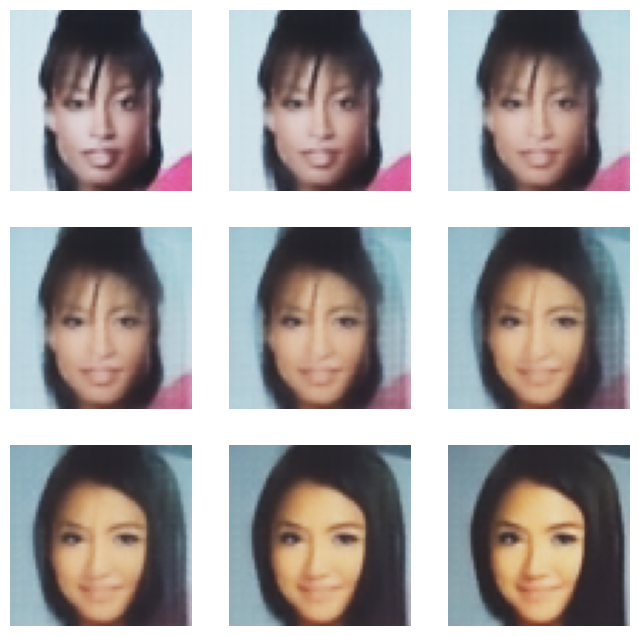

In [5]:
import random
from matplotlib import pyplot as plt

sampleA = test_dataset[random.randint(0,len(test_dataset)-1)][0]
sampleB = test_dataset[random.randint(0,len(test_dataset)-1)][0]

with torch.inference_mode():
    muA,logstdA = vae.encode(sampleA[None])
    muB,logstdB = vae.encode(sampleB[None])
    
    t = torch.linspace(0,1,9)[:,None,None,None]
    interpolation = torch.lerp(muA,muB,t)
    dec = vae.decode(interpolation)

print(muA.std(),muB.std())

# display(T.ToPILImage()(sampleA.sigmoid()).resize((192,192),0))
# display(T.ToPILImage()(sampleB.sigmoid()).resize((192,192),0))
plt.figure(figsize=(8,8))
for ind,i in enumerate(dec):
    plt.subplot(3,3,ind+1)
    plt.imshow(T.ToPILImage()(i.sigmoid()))
    plt.axis('off')
plt.show()

In [6]:
class ImageLatentsDataset(torch.utils.data.Dataset):
    def __init__(self,images_dataset:torch.utils.data.Dataset,vae : VAE):
        super().__init__()
        self.images_dataset=images_dataset
        self.vae=vae.cpu()
    def __len__(self):return len(self.images_dataset)
    def __getitem__(self, index):
        im = self.images_dataset[index][0]
        with torch.inference_mode():
            latent = self.vae.encode(im[None,:])[0][0]
        return latent,0

latents_dataset = ImageLatentsDataset(dataset,vae)
latents_dataset = PrefetchDataset(latents_dataset,"./latents")
train_latents_dataset,test_latents_dataset,train_latents_loader, test_latents_loader = split_dataset(latents_dataset,batch_size=64,shuffle=True)

Train items 41317
Test items 2175


In [7]:
from kemsekov_torch.ViT import FlowModel2d

fm = FlowModel2d(vae.latent_dim,hidden_dim=256,attention_layers=[6,4,3],compression_rates=[1,2,4])

def compute_loss_and_metric(model : FlowModel2d,batch):
    x = batch[0]/3
    return model.train_loss_and_metric(x,contrastive_loss_weight=0.1)
# _ = train(
#     fm,
#     train_latents_loader,
#     test_latents_loader,
#     compute_loss_and_metric,
#     save_on_metric_improve=["r2"],
#     save_results_dir="./faces-fm-vae",
#     num_epochs=500,
#     load_checkpoint_dir="./faces-fm-vae/last",
#     gradient_clipping_max_norm=1,
#     accelerate_args={
#         'mixed_precision':'bf16',
#         'dynamo_backend':'inductor'
#     },
#     ema_args={
#         'beta':0.999,
#         'update_model_with_ema_every':100
#     },
# )

Loading last checkpoint at epoch 127


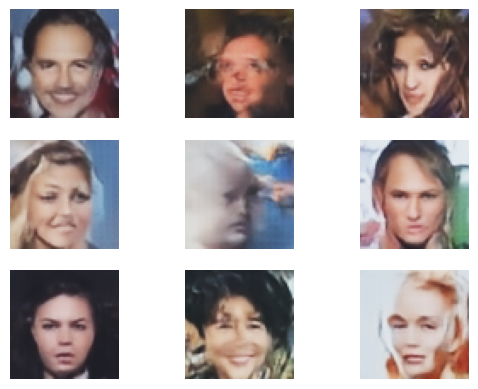

In [70]:
from kemsekov_torch.ViT import FlowModel2d
fm : FlowModel2d = load_last_checkpoint(fm,"faces-fm-vae").eval()

with torch.no_grad():
    sample = fm.sample(9,(16,16)).cpu()*3
    dec = vae.decode(sample)
for i,im in enumerate(dec):
    plt.subplot(3,3,i+1)
    plt.imshow(T.ToPILImage()(im.sigmoid()))
    plt.axis("off")

Text(0.5, 1.0, 'Latent 2/2')

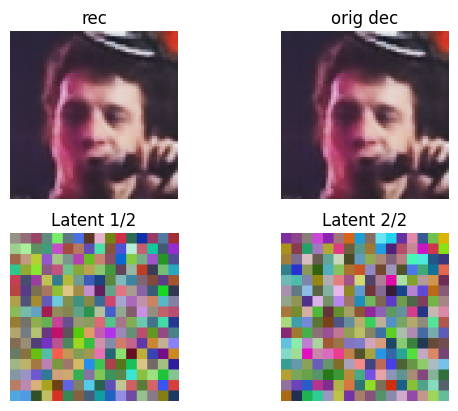

In [9]:
with torch.no_grad():
    sampleA = latents_dataset[random.randint(0,len(latents_dataset)-1)][0][None,:]
    priorA = fm.to_prior(sampleA/3)
    rec = fm.to_target(priorA)*3
    rec_im = vae.decode(rec)
    orig_dec = vae.decode(sampleA)
plt.subplot(2,2,1)
plt.imshow(T.ToPILImage()(rec_im[0].sigmoid()).resize((128,128),0))
plt.axis("off")
plt.title("rec")
plt.subplot(2,2,2)
plt.imshow(T.ToPILImage()(orig_dec[0].sigmoid()).resize((128,128),0))
plt.axis("off")
plt.title("orig dec")
plt.subplot(2,2,3)
plt.imshow(T.ToPILImage()(priorA[0,:3].sigmoid()).resize((128,128),0))
plt.axis("off")
plt.title("Latent 1/2")
plt.subplot(2,2,4)
plt.imshow(T.ToPILImage()(priorA[0,3:].sigmoid()).resize((128,128),0))
plt.axis("off")
plt.title("Latent 2/2")

In [10]:
from tqdm import tqdm
import os

# generate fm latents dataset
# os.makedirs("./fm-latents",exist_ok=True)
# index = 0
# with torch.no_grad():
#     for loader in [train_latents_loader,test_latents_loader]:
#         for b in tqdm(loader,total=len(loader)):
#             latents = b[0]/3
#             prior = fm.to_prior(latents).detach().cpu().clone()
#             for lat,pr in zip(latents,prior):
#                 torch.save((lat,pr),f"./fm-latents/{index}.obj")
#                 index+=1

In [11]:
fm_latents_dataset = FolderDataset('./fm-latents')
train_fm_latents_dataset,test_fm_latents_dataset,train_fm_latents_loader, test_fm_latents_loader \
    = split_dataset(fm_latents_dataset,batch_size=64,shuffle=True)

Train items 41222
Test items 2170


In [12]:
from copy import deepcopy
fm_reflow = deepcopy(fm)
fm_reflow.default_steps+=1-fm_reflow.default_steps

In [13]:
from kemsekov_torch.ViT import FlowModel2d
def compute_loss_and_metric(model : FlowModel2d,batch):
    x1,x0 = batch
    return model.reflow_loss_and_metric(x0,x1)
# reflow model
# _ = train(
#     fm,
#     train_fm_latents_loader,
#     test_fm_latents_loader,
#     compute_loss_and_metric,
#     save_on_metric_improve=["r2"],
#     save_results_dir="./faces-fm-vae-reflow",
#     load_checkpoint_dir="./faces-fm-vae-reflow/last",
#     num_epochs=500,
#     gradient_clipping_max_norm=1,
#     accelerate_args={
#         'mixed_precision':'bf16',
#         'dynamo_backend':'inductor'
#     },
#     ema_args={
#         'beta':0.999,
#         'update_model_with_ema_every':100
#     },
# )

Loading last checkpoint at epoch 10


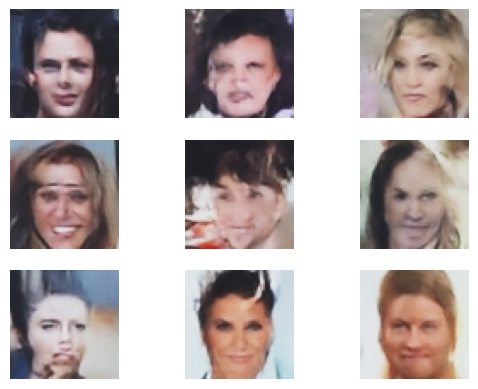

In [80]:
fm_reflow : FlowModel2d = load_last_checkpoint(fm_reflow,"faces-fm-vae-reflow").eval()
with torch.no_grad():
    sample = fm_reflow.sample(9,(16,16)).cpu()*3
    dec = vae.decode(sample)
for i,im in enumerate(dec):
    plt.subplot(3,3,i+1)
    plt.imshow(T.ToPILImage()(im.sigmoid()))
    plt.axis("off")

In [81]:
# sample[1]+=torch.rand_like(sample[3])
sample[0,:]=sample.mean(0,keepdim=True)
sample[-1,:]=-20

with torch.no_grad():
    logp = fm_reflow.log_prob(sample,random_directions=8,eps=0.01)/1000
logp

tensor([   8.1229,    3.2614,    5.4838,    4.7405,    2.5925,    4.4063,
           4.4195,    2.1847, -422.9264])

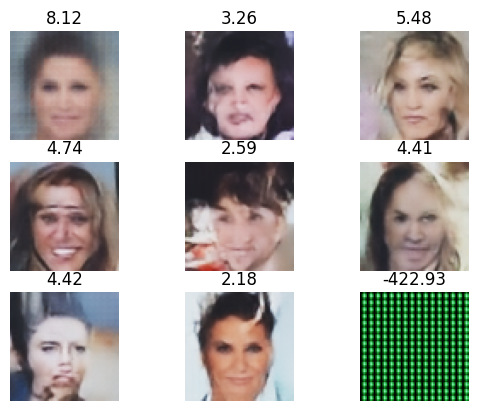

In [82]:
# see example how log prob works
with torch.no_grad():
    for i in (-logp).argsort():
        im = vae.decode(sample[i][None])[0]
        plt.subplot(3,3,i.item()+1)
        plt.imshow(T.ToPILImage()(im.sigmoid()))
        plt.axis("off")
        plt.title(f"{logp[i]:0.2f}")